In [87]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pathlib as Path
import sys
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans


DATA_DIR = Path.Path("/Users/joshi/Desktop/Remote Sensing Data Analysis/HW2/data")
dataStrings = ["AIA20100513_0000_0094.npz", "AIA20100513_0000_0131.npz", "AIA20100513_0000_0171.npz", "AIA20100513_0000_0193.npz", "AIA20100513_0000_0211.npz", "AIA20100513_0000_0304.npz", "AIA20100513_0000_0335.npz", "AIA20100513_0000_1600.npz", ]

## Data Description

8 AIA wavelength images at the same time. Pixels are samples N, wavelengths are features D. \(N=262144\), \(D=8\).

In [88]:
# Data is multiple wavelengths from the same day -- 8 wavelengths in this case
data = []
for file_idx in range(len(dataStrings)):
    with np.load(DATA_DIR / dataStrings[file_idx]) as dataRead:
        print("Data keys:", dataRead.files)
        data.append(dataRead['x'])
        for key in dataRead.files:
            print(f"Key: {key}, Shape: {dataRead[key].shape}")

Data keys: ['x']
Key: x, Shape: (512, 512)
Data keys: ['x']
Key: x, Shape: (512, 512)
Data keys: ['x']
Key: x, Shape: (512, 512)
Data keys: ['x']
Key: x, Shape: (512, 512)
Data keys: ['x']
Key: x, Shape: (512, 512)
Data keys: ['x']
Key: x, Shape: (512, 512)
Data keys: ['x']
Key: x, Shape: (512, 512)
Data keys: ['x']
Key: x, Shape: (512, 512)


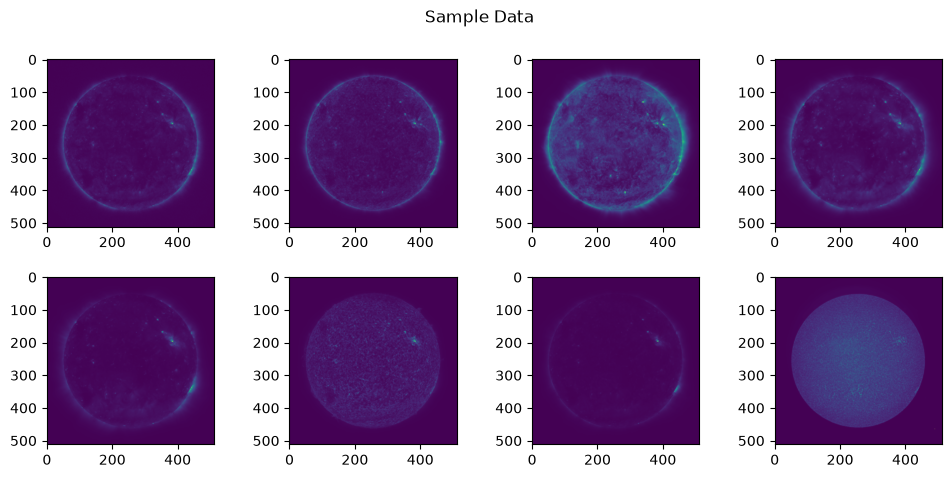

In [89]:
plt.figure(figsize=(12,5))
plt.subplots_adjust(hspace=0.3)
plt.suptitle("Sample Data")

plt.subplot(241); plt.imshow(data[0])

plt.subplot(242); plt.imshow(data[1])

plt.subplot(243); plt.imshow(data[2])

plt.subplot(244); plt.imshow(data[3])

plt.subplot(245); plt.imshow(data[4])

plt.subplot(246); plt.imshow(data[5])

plt.subplot(247); plt.imshow(data[6])

plt.subplot(248); plt.imshow(data[7])


plt.show()

In [90]:
# data processing
data = np.array(data) # 8 WL, 512 x 512 px
print("Data shape:", data.shape)

dataStacked = np.moveaxis(data, 0, -1) # converted to 512 x 512 px with 8 WL as the last dimension
print("Stacked data shape:", dataStacked.shape)

flattenedData = dataStacked.reshape(-1, 8) # each pixel now corresponds to 8 WL features
print("Raw data shape for K-Means:", flattenedData.shape, "\n")

validity = np.isfinite(flattenedData).all(axis=1) # check to confirm all values are valid and not inf, NaN, or invalid
print("Validity check for each pixel:", validity)
print("Number of valid pixels:", np.sum(validity))

# removing unclean data
if np.sum(validity) == flattenedData.shape[0]:
    print("All valid pixels in data.", "\n")
    flattenedData = flattenedData[validity] # keep only valid pixels

else:
    print("Some invalid pixels found and removed.", "\n")
    flattenedData = flattenedData[validity] # keep only valid pixels


# data properties
N = flattenedData.shape[0] # nSamples
print("Number of samples:", N)

D = flattenedData.shape[1] # nFeatures
print("Number of features per sample:", D)

Data shape: (8, 512, 512)
Stacked data shape: (512, 512, 8)
Raw data shape for K-Means: (262144, 8) 

Validity check for each pixel: [ True  True  True ...  True  True  True]
Number of valid pixels: 262144
All valid pixels in data. 

Number of samples: 262144
Number of features per sample: 8


In [91]:
# data standardisation
print("Data mean before standardisation:", np.mean(flattenedData, axis=(0)))
print("Data standard deviation before standardisation:", np.std(flattenedData, axis=(0)), "\n")

flattenedData = (flattenedData - np.mean(flattenedData, axis=0)) / np.std(flattenedData, axis=0)
print("Data mean after standardisation:", (np.mean(flattenedData, axis=(0))))
print("Data standard deviation after standardisation:",  (np.std(flattenedData, axis=(0))))

X = flattenedData

Data mean before standardisation: [  1.8923583  11.96473   430.55017   407.9909    112.01061   111.16443
   6.3977613 142.09406  ]
Data standard deviation before standardisation: [  2.3448107  14.630874  437.89636   488.5827    155.79802   119.74884
   9.470757  144.89978  ] 

Data mean after standardisation: [-4.4164199e-06  2.0176253e-06  1.7533253e-05  6.2855675e-06
  4.6652844e-05  8.9166628e-05 -3.1876314e-06  1.4853675e-04]
Data standard deviation after standardisation: [1.0000176  1.0000019  1.0000514  0.99998206 1.0000954  1.0000023
 1.0000153  0.99992853]


In [92]:
# K-Means Clustering - minimise within cluster variance

def calculateCost(inData, centers, labels):
    diff = inData - centers[labels]
    
    cost_J_L22 = np.sum(diff ** 2)
    cost_J_L2 = np.sum(np.sqrt(np.sum(diff ** 2, axis=1)))
    cost_J_L1 = np.sum(np.abs(diff))

    return cost_J_L1, cost_J_L2, cost_J_L22

def KMeans(inData, K, nIters, seed):
    print(f"Maximum number of iterations per run: {nIters}")
    print(f"K-Means with K={K} and seed={seed}")
    
    np.random.seed(seed)

    centers = inData[np.random.choice(inData.shape[0], K, replace=False)].copy() #replace = False makes sure EACH centroid is unique, shape: K x D

    for i in range(nIters):
        lastCenters = centers.copy()

        # assign each data point to the nearest cluster
        distanceSq = np.sum(
            (inData[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2,
              axis=2) # squared Euclidean distance between each data point and each cluster center
        
        labels = np.argmin(distanceSq, axis=1) # cluster number for each pixel decided by minimum distance from the cluster centers

        # update cluster centers
        for k in range(K):
            members = inData[labels == k] # all pixels assigned to cluster number k

            if members.size > 0:
                centers[k] = members.mean(axis=0)

            # convergence check
        if np.allclose(centers, lastCenters):
            print(f"Converged after {i+1} iterations \n")
            break
    else:
        print(f"Reached maximum iterations ({nIters}) without convergence \n")

        # Assign labels one final time using the final centers
    distanceSq = np.sum(
        (inData[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2,
        axis=2) # update labels one final time using the final centers
    
    labels = np.argmin(distanceSq, axis=1)

    cost_J_L1, cost_J_L2, cost_J_L22 = calculateCost(inData, centers, labels)

    return centers, labels, cost_J_L1, cost_J_L2, cost_J_L22

def GMM(X, K_gmm, seed):

    gmm = GaussianMixture(
        n_components=K_gmm,
        covariance_type="full",
        n_init=3,                # tries three initializations and keeps the best
        max_iter=500,
        random_state=seed
    )
    labelsGMM = gmm.fit_predict(X) # Fit the GMM and assign each pixel to its most likely Gaussian component
    centersGMM = gmm.means_ # Each Gaussian mean is an 8-wavelength cluster center
    probabilitiesGMM = gmm.predict_proba(X) # GMM also gives a probability of belonging to every cluster

    print("GMM cluster centers shape:", centersGMM.shape)
    print("Pixels in each GMM cluster:", np.bincount(labelsGMM, minlength=K_gmm))
    print("AIC:", gmm.aic(X))
    print("BIC:", gmm.bic(X))

    gmmL1, gmmL2, gmmSquared = calculateCost(X, centersGMM, labelsGMM)
    print("GMM cost (L1):", gmmL1)
    print("GMM cost (L2):", gmmL2)
    print("GMM cost (Squared L2):", gmmSquared)

    return labelsGMM, centersGMM, probabilitiesGMM, gmm.aic(X), gmm.bic(X), gmmL1, gmmL2, gmmSquared

def plotCost(cost_J_Set, loss_type):
    plt.figure(figsize=(8,3))
    for i, seed in enumerate(seeds):
        plt.plot(arrK, cost_J_Set[i], marker="x", label=f"Seed {seed}")
    plt.xlabel("Number of clusters, K")
    plt.ylabel(loss_type)
    plt.legend()
    plt.grid(True)
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    plt.xlim(arrK[0], arrK[-1])
    plt.ylim(0, np.max(cost_J_Set))
    plt.show()

    return 0

def plotReconstruction(idxSeed, idxK, arrK, labelSet, centerSet):

    idxReconstruct = idxSeed * len(arrK) + idxK - 1
    labelReconstruct = labelSet[idxReconstruct]
    centerReconstruct = centerSet[idxReconstruct]
    reconstructedData = centerReconstruct[labelReconstruct].reshape(512,512,8)
    plt.figure(figsize=(12,5))
    plt.subplots_adjust(hspace=0.3)
    plt.suptitle(f"Reconstructed Data: K={idxK}, seed={seeds[idxSeed]}")
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(reconstructedData[:, :, i])

    plt.show()

    return reconstructedData[:,:,:], labelReconstruct, centerReconstruct


def plotClusterMap(recon, reconLabel, reconCenter, idxK, seed):

    plt.figure(figsize=(7, 6))
    plt.imshow(reconLabel.reshape(512, 512), cmap = "tab10", vmin=0, vmax=idxK-1)
    plt.title(f"K Means Clusters, K = {idxK}, seed = {seed}")
    plt.colorbar(label="Cluster Number")
    plt.show()

    return 0


In [93]:
centerSet, labelSet, cost_J_L1_Set, cost_J_L2_Set, cost_J_L22_Set = [], [], [], [], []

nK = 10
seeds = [0, 16, 42]
arrK = np.arange(1, nK + 1, 1)

for seed in seeds:
    for K in arrK:
        center, label, cost_J_L1_val, cost_J_L2_val, cost_J_L22_val = KMeans(X, K=K, nIters=200, seed=seed)
        centerSet.append(center)
        labelSet.append(label)
        cost_J_L1_Set.append(cost_J_L1_val)
        cost_J_L2_Set.append(cost_J_L2_val)
        cost_J_L22_Set.append(cost_J_L22_val)
        print(f"Seed: {seed}, K: {K}, Cost J_L1: {cost_J_L1_val}, Cost J_L2: {cost_J_L2_val}, Cost J_L22: {cost_J_L22_val}")
        print()

cost_J_L1_Set = np.reshape(cost_J_L1_Set, (len(seeds),len(arrK)))
cost_J_L2_Set = np.reshape(cost_J_L2_Set, (len(seeds),len(arrK)))
cost_J_L22_Set = np.reshape(cost_J_L22_Set, (len(seeds),len(arrK)))

Maximum number of iterations per run: 200
K-Means with K=1 and seed=0
Converged after 2 iterations 

Seed: 0, K: 1, Cost J_L1: 1441838.0, Cost J_L2: 583541.25, Cost J_L22: 2097277.75

Maximum number of iterations per run: 200
K-Means with K=2 and seed=0
Converged after 11 iterations 

Seed: 0, K: 2, Cost J_L1: 879985.5, Cost J_L2: 361744.71875, Cost J_L22: 1308165.5

Maximum number of iterations per run: 200
K-Means with K=3 and seed=0
Converged after 34 iterations 

Seed: 0, K: 3, Cost J_L1: 717417.0625, Cost J_L2: 302278.9375, Cost J_L22: 783849.1875

Maximum number of iterations per run: 200
K-Means with K=4 and seed=0
Converged after 49 iterations 

Seed: 0, K: 4, Cost J_L1: 635084.875, Cost J_L2: 272318.5, Cost J_L22: 620030.125

Maximum number of iterations per run: 200
K-Means with K=5 and seed=0
Converged after 106 iterations 

Seed: 0, K: 5, Cost J_L1: 609841.0, Cost J_L2: 262636.53125, Cost J_L22: 500956.1875

Maximum number of iterations per run: 200
K-Means with K=6 and see

In [94]:
print(len(centerSet))
print(len(labelSet))
print(cost_J_L1_Set.shape)
print(cost_J_L2_Set.shape)
print(cost_J_L22_Set.shape)

if len(centerSet) == len(labelSet) and cost_J_L1_Set.shape == cost_J_L2_Set.shape == cost_J_L22_Set.shape:
    print("All centroid and label sets have the same length.")
    print("All cost sets have the same shape.")
else:
    print("Sets have different shapes.")

30
30
(3, 10)
(3, 10)
(3, 10)
All centroid and label sets have the same length.
All cost sets have the same shape.


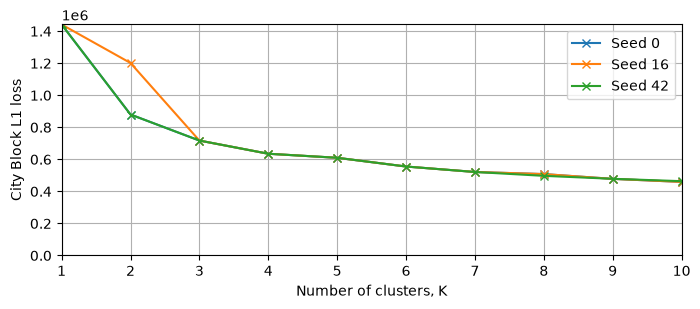

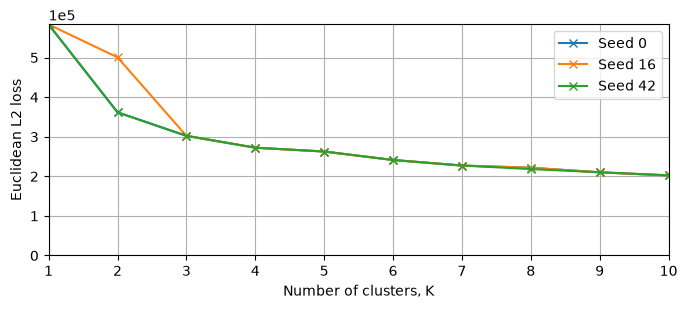

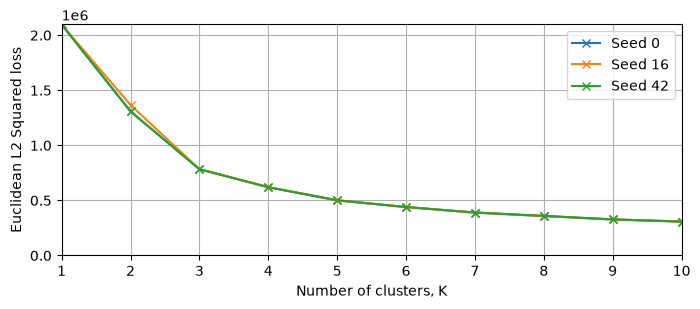

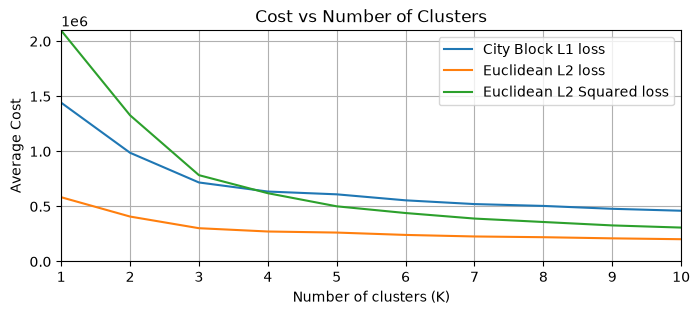

In [95]:
#print(cost_J_L2_Set.shape); print(cost_J_L22_Set.shape); print(cost_J_L1_Set.shape)

plotCost(cost_J_L1_Set, "City Block L1 loss")
plotCost(cost_J_L2_Set, "Euclidean L2 loss")
plotCost(cost_J_L22_Set, "Euclidean L2 Squared loss")

plt.figure(figsize=(8, 3))
plt.plot(arrK, cost_J_L1_Set.mean(axis=0), label="City Block L1 loss")
plt.plot(arrK, cost_J_L2_Set.mean(axis=0), label="Euclidean L2 loss")
plt.plot(arrK, cost_J_L22_Set.mean(axis=0), label="Euclidean L2 Squared loss")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Average Cost")
plt.title("Cost vs Number of Clusters")
plt.xlim(1, 10)
plt.ylim(0, np.max([cost_J_L1_Set, cost_J_L2_Set, cost_J_L22_Set]))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.grid(True)
plt.legend()
plt.show()

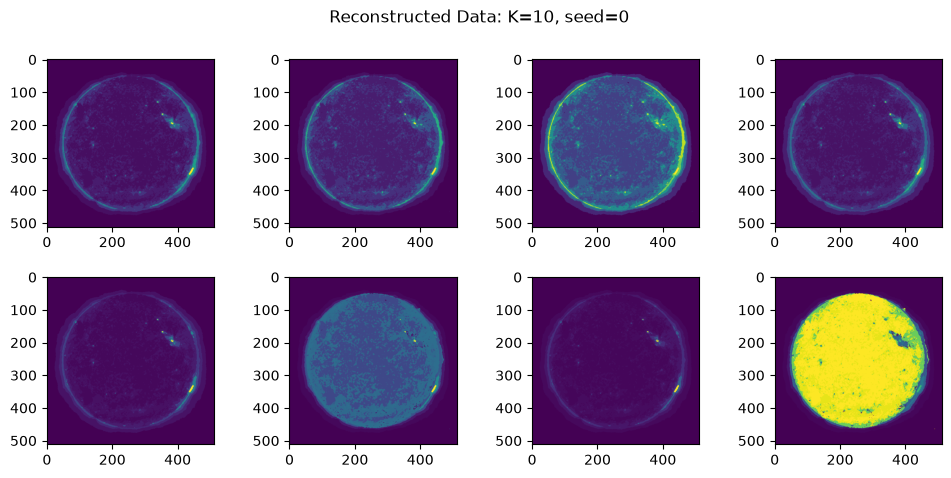

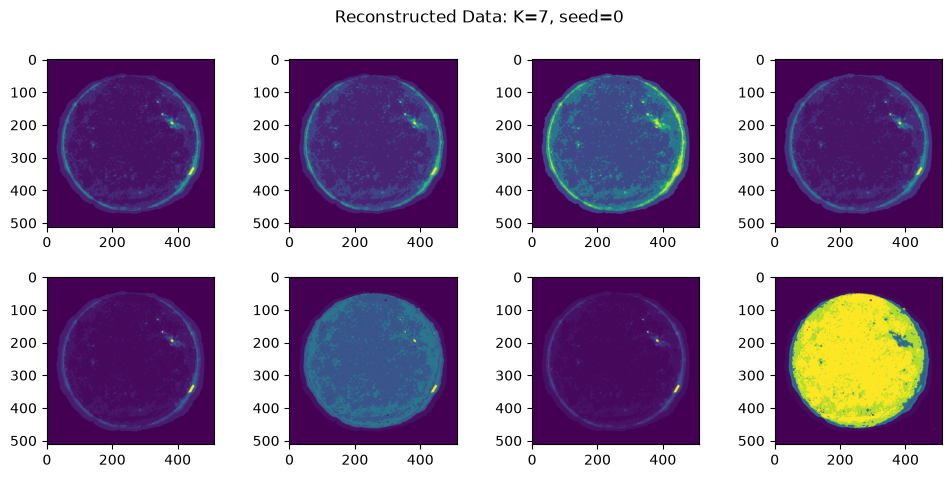

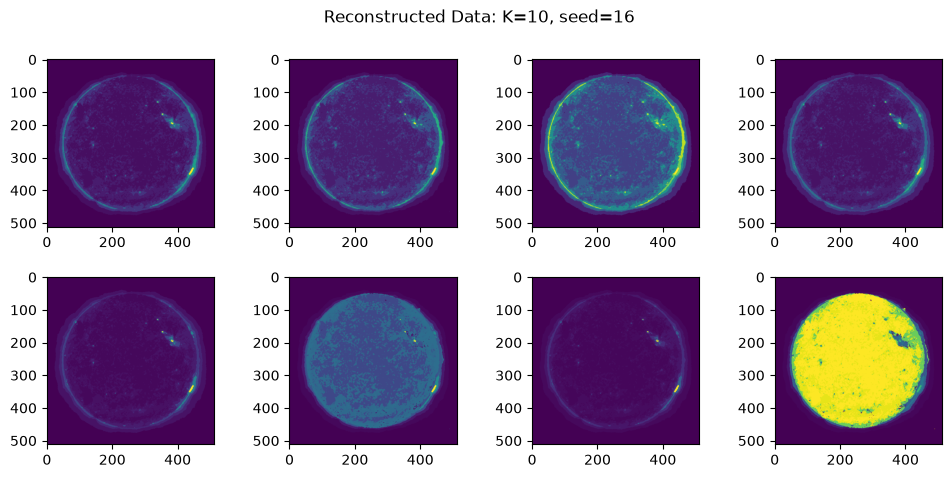

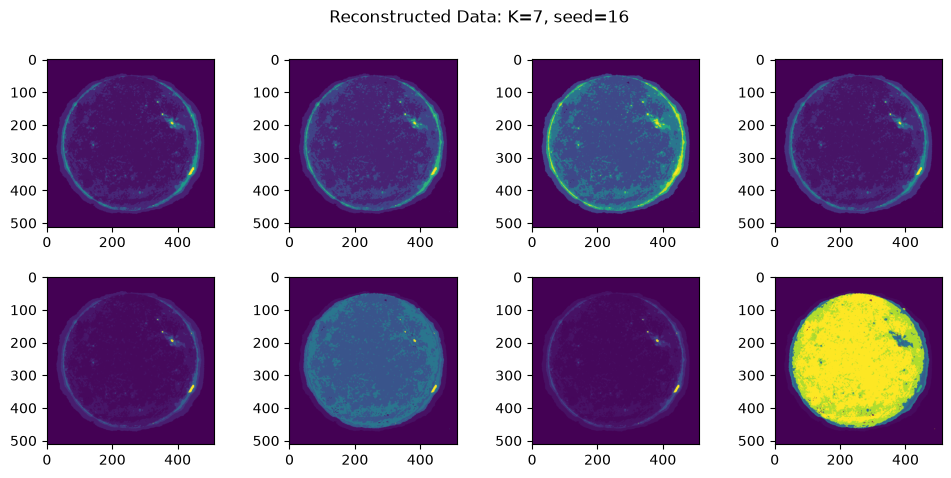

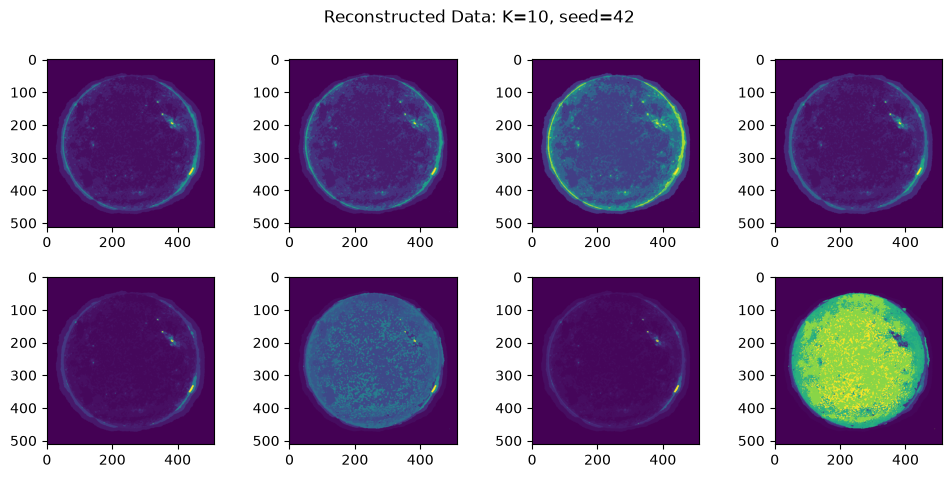

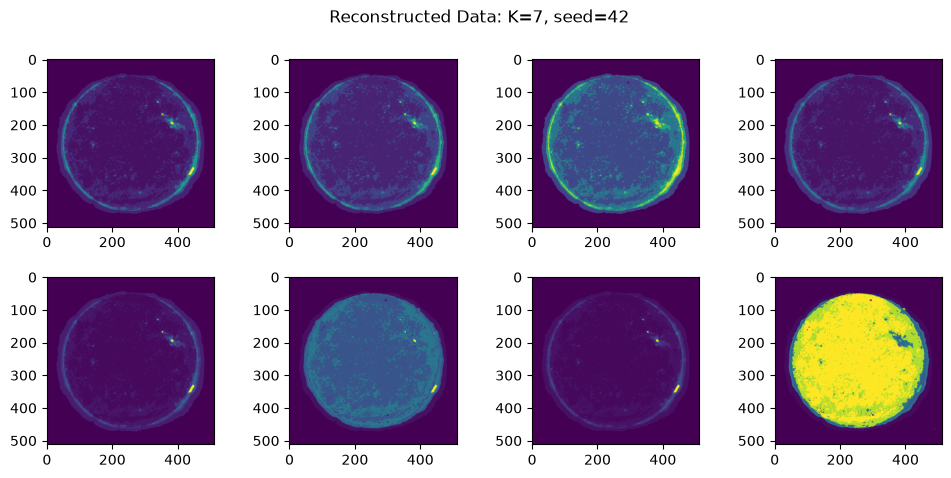

In [96]:
recon010, labels010, centers010 = plotReconstruction(0, 10, arrK, labelSet, centerSet)
recon07, labels07, centers07 = plotReconstruction(0, 7, arrK, labelSet, centerSet)
recon110, labels110, centers110 = plotReconstruction(1, 10, arrK, labelSet, centerSet)
recon17, labels17, centers17 = plotReconstruction(1, 7, arrK, labelSet, centerSet)
recon210, labels210, centers210 = plotReconstruction(2, 10, arrK, labelSet, centerSet)
recon27, labels27, centers27 = plotReconstruction(2, 7, arrK, labelSet, centerSet)

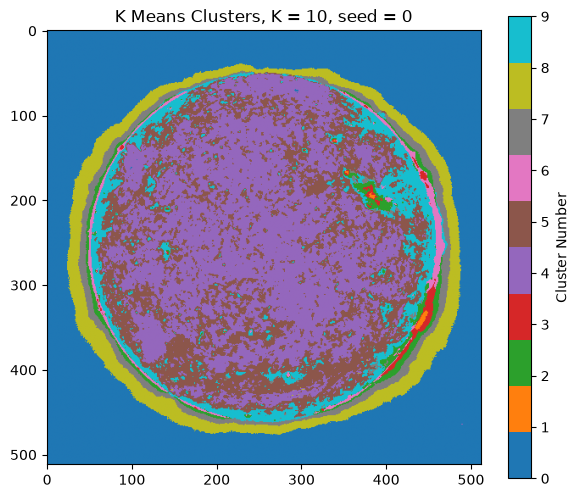

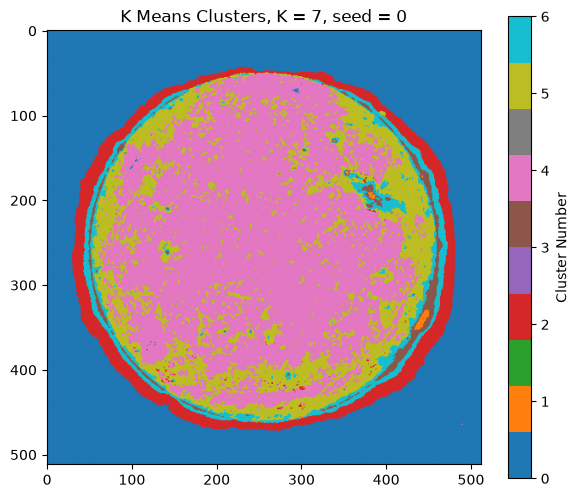

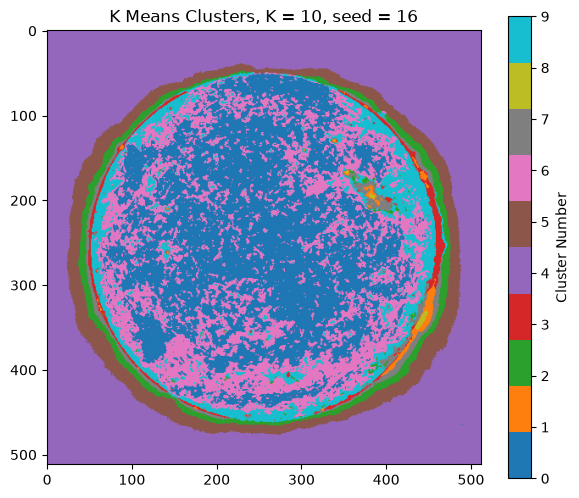

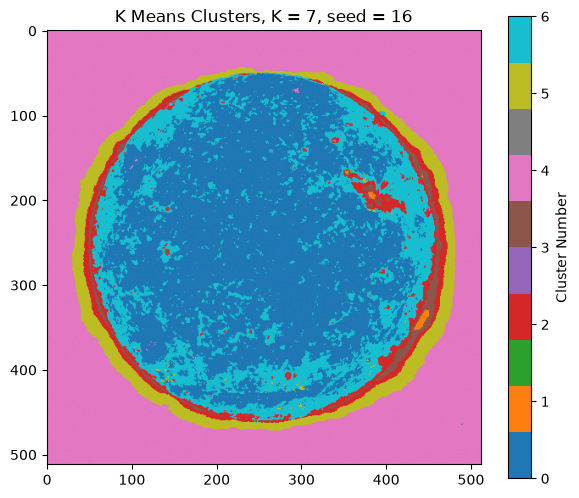

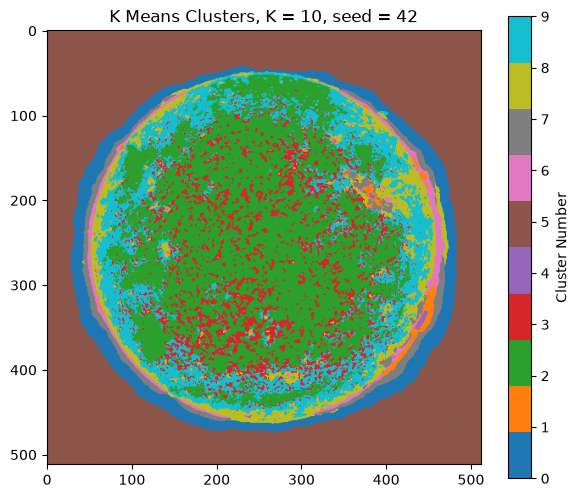

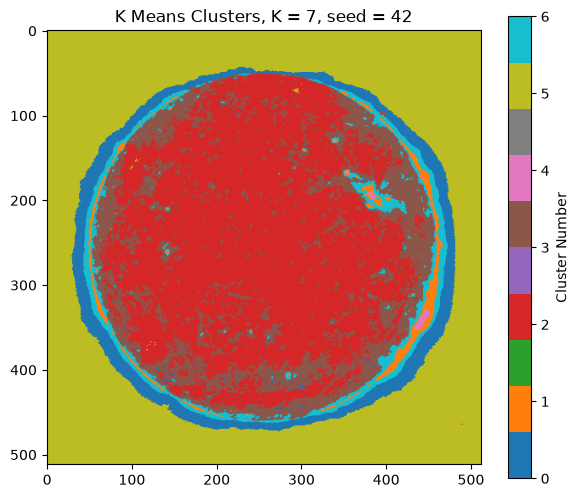

0

In [97]:
plotClusterMap(recon010, labels010, centers010, 10, 0)
plotClusterMap(recon07, labels07, centers07, 7, 0)

plotClusterMap(recon110, labels110, centers110, 10, 16)
plotClusterMap(recon17, labels17, centers17, 7, 16)

plotClusterMap(recon210, labels210, centers210, 10, 42)
plotClusterMap(recon27, labels27, centers27, 7, 42)


In [98]:
# Gaussian Mixture Model clustering
gmmK = np.arange(1, 11)

labelsGMM, centersGMM, probabilitiesGMM, aic, bic, gmmL1, gmmL2, gmmSquared = [], [], [], [], [], [], [], []

for K_gmm in gmmK:
    labelsGMM_, centersGMM_, probabilitiesGMM_, aic_, bic_, gmmL1_, gmmL2_, gmmSquared_ = GMM(X, K_gmm, seed=16)
    labelsGMM.append(labelsGMM_)
    centersGMM.append(centersGMM_)
    probabilitiesGMM.append(probabilitiesGMM_)
    aic.append(aic_)
    bic.append(bic_)
    gmmL1.append(gmmL1_)
    gmmL2.append(gmmL2_)
    gmmSquared.append(gmmSquared_)
    print(f"K = {K_gmm}, AIC = {aic_}, BIC = {bic_}, GMM cost (L1) = {gmmL1_}, GMM cost (L2) = {gmmL2_}, GMM cost (Squared L2) = {gmmSquared_}") 

gmmL1 = np.array(gmmL1)
gmmL2 = np.array(gmmL2)
gmmSquared = np.array(gmmSquared)

GMM cluster centers shape: (1, 8)
Pixels in each GMM cluster: [262144]
AIC: 2469624.0
BIC: 2470084.9725670037
GMM cost (L1): 1.4418382e+06
GMM cost (L2): 583541.4
GMM cost (Squared L2): 2.097278e+06
K = 1, AIC = 2469624.0, BIC = 2470084.9725670037, GMM cost (L1) = 1441838.25, GMM cost (L2) = 583541.375, GMM cost (Squared L2) = 2097278.0
GMM cluster centers shape: (2, 8)
Pixels in each GMM cluster: [165069  97075]
AIC: -858370.375
BIC: -857437.953216743
GMM cost (L1): 898429.06
GMM cost (L2): 370485.9
GMM cost (Squared L2): 1.4041049e+06
K = 2, AIC = -858370.375, BIC = -857437.953216743, GMM cost (L1) = 898429.0625, GMM cost (L2) = 370485.90625, GMM cost (Squared L2) = 1404104.875
GMM cluster centers shape: (3, 8)
Pixels in each GMM cluster: [ 92876 142040  27228]
AIC: -2066964.125
BIC: -2065560.2540004894
GMM cost (L1): 760371.06
GMM cost (L2): 324039.2
GMM cost (Squared L2): 1.01021425e+06
K = 3, AIC = -2066964.125, BIC = -2065560.2540004894, GMM cost (L1) = 760371.0625, GMM cost (L2)

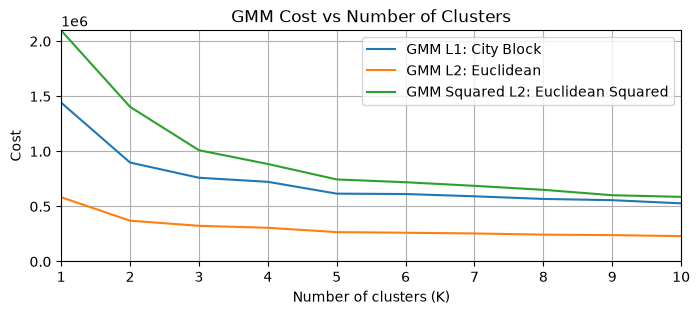

In [99]:
plt.figure(figsize=(8, 3))
plt.plot(gmmK, gmmL1, label="GMM L1: City Block")
plt.plot(gmmK, gmmL2, label="GMM L2: Euclidean")
plt.plot(gmmK, gmmSquared, label="GMM Squared L2: Euclidean Squared")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Cost")
plt.title("GMM Cost vs Number of Clusters")
plt.legend()
plt.xlim(1, max(gmmK))
plt.ylim(0, max(gmmL1.max(), gmmL2.max(), gmmSquared.max()))
plt.grid(True)
plt.show()

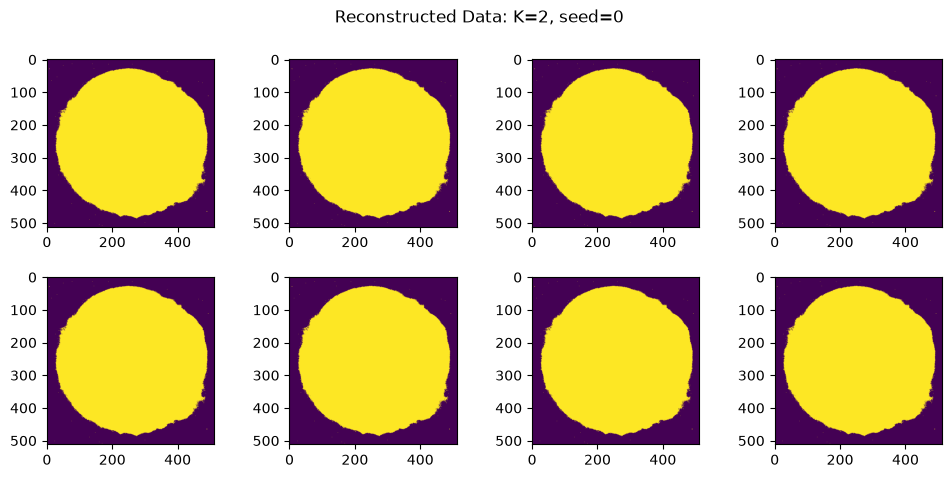

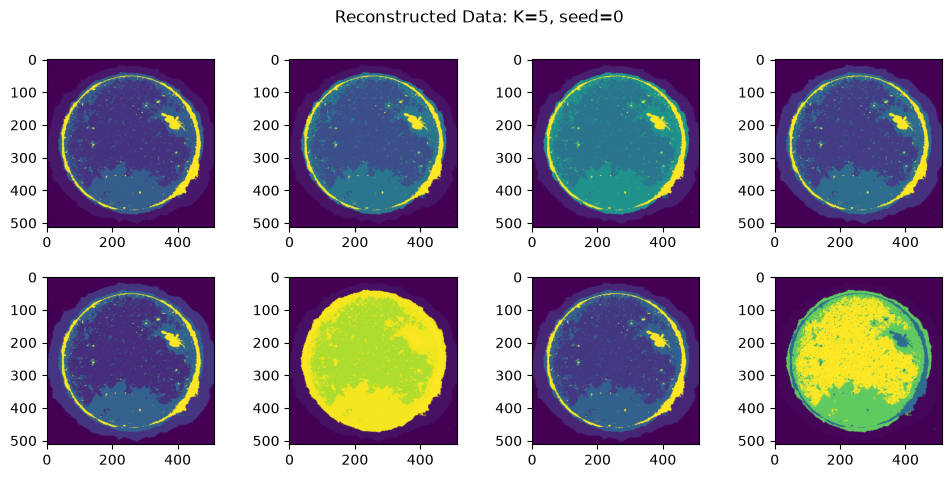

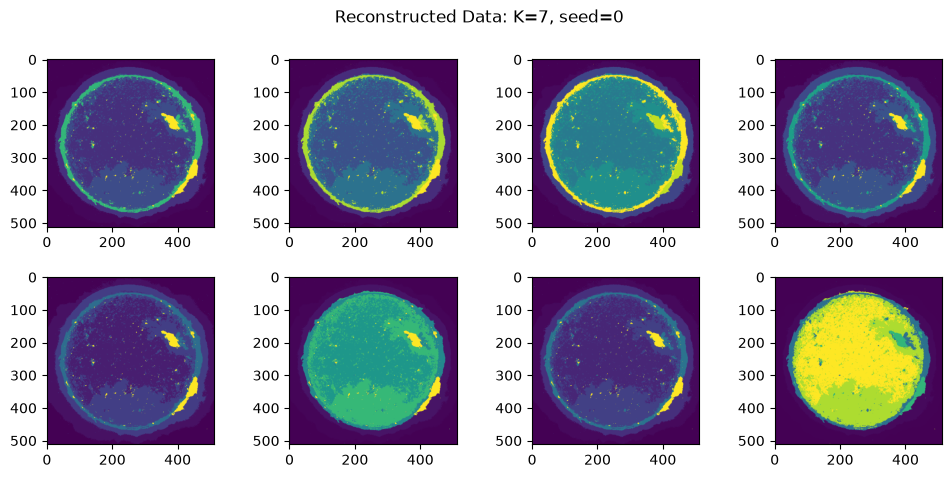

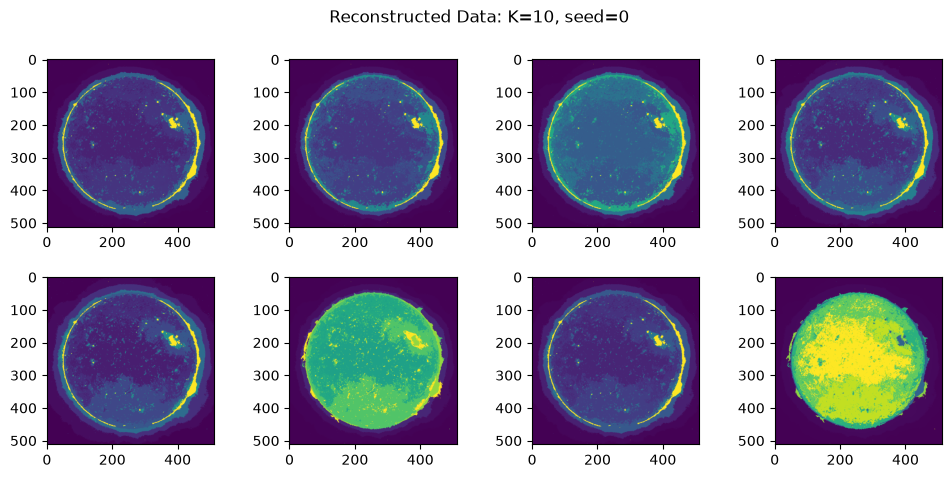

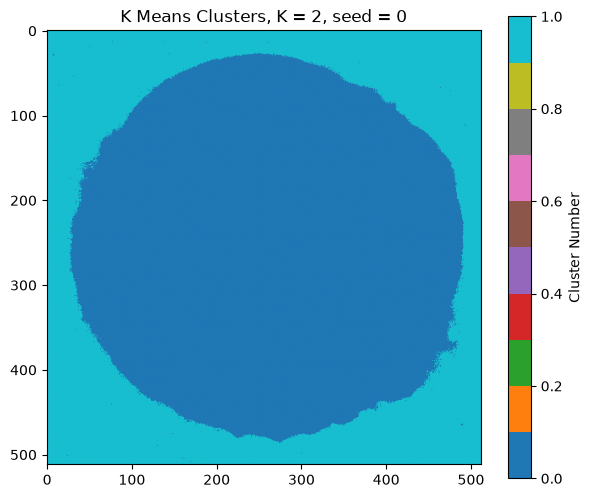

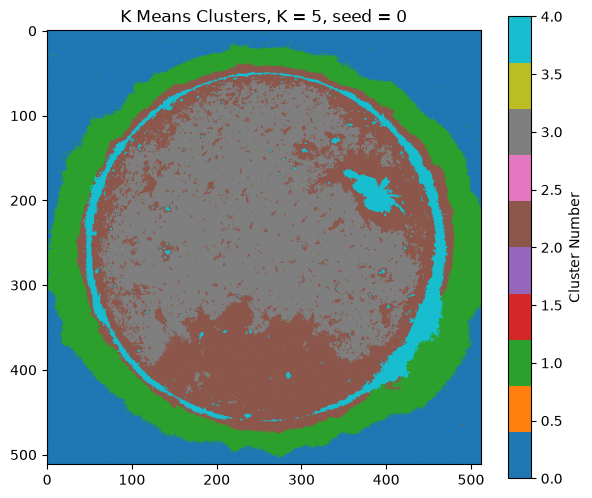

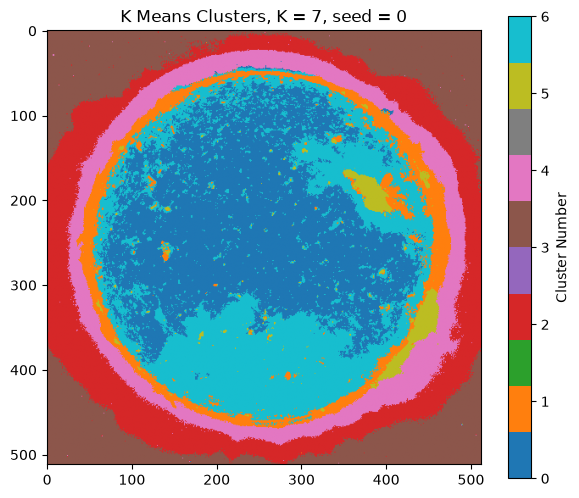

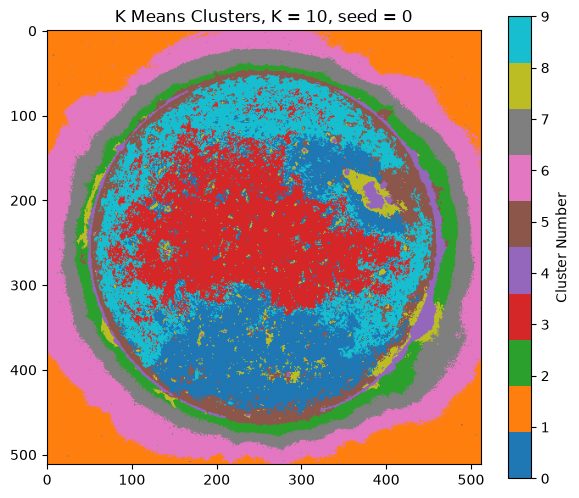

0

In [100]:
# GMM Reconstruction
GMMrecon2, GMMlabel2, GMMcenter2 = plotReconstruction(0, 2, gmmK, labelsGMM, centersGMM)
GMMrecon5, GMMlabel5, GMMcenter5 = plotReconstruction(0, 5, gmmK, labelsGMM, centersGMM)
GMMrecon7, GMMlabel7, GMMcenter7 = plotReconstruction(0, 7, gmmK, labelsGMM, centersGMM)
GMMrecon10, GMMLabel10, GMMcenter10 = plotReconstruction(0, 10, gmmK, labelsGMM, centersGMM)


# Cluster Map
plotClusterMap(GMMrecon2, GMMlabel2, GMMcenter2, 2, 0)
plotClusterMap(GMMrecon5, GMMlabel5, GMMcenter5, 5, 0)
plotClusterMap(GMMrecon7, GMMlabel7, GMMcenter7, 7, 0)
plotClusterMap(GMMrecon10, GMMLabel10, GMMcenter10, 10, 0)

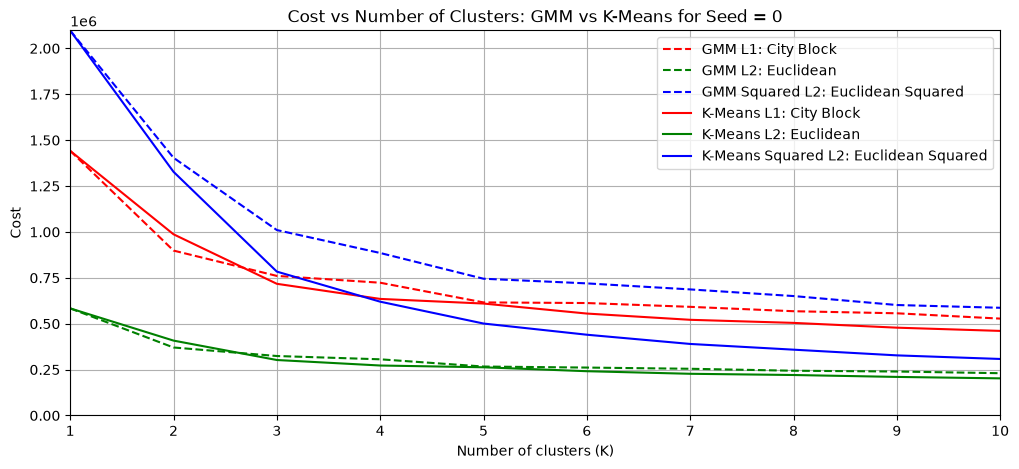

In [101]:
plt.figure(figsize=(12, 5))
plt.plot(gmmK, gmmL1, color = 'r', linestyle = '--', label="GMM L1: City Block")
plt.plot(gmmK, gmmL2, color = 'g', linestyle = '--', label="GMM L2: Euclidean")
plt.plot(gmmK, gmmSquared, color = 'b', linestyle = '--', label="GMM Squared L2: Euclidean Squared")
plt.plot(arrK, cost_J_L1_Set.mean(axis=0), color = 'r', linestyle = '-', label="K-Means L1: City Block")
plt.plot(arrK, cost_J_L2_Set.mean(axis=0), color = 'g', linestyle = '-', label="K-Means L2: Euclidean")
plt.plot(arrK, cost_J_L22_Set.mean(axis=0), color = 'b', linestyle = '-',  label="K-Means Squared L2: Euclidean Squared")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Cost")
plt.title("Cost vs Number of Clusters: GMM vs K-Means for Seed = 0")
plt.legend()
plt.xlim(1, max(gmmK))
plt.ylim(0, max(gmmL1.max(), gmmL2.max(), gmmSquared.max()))
plt.grid(True)
plt.show()